# Efficient Frontier Optimization -- Crypto Portfolio (Markowitz)

Modern Portfolio Theory applied to a basket of six real crypto assets
(`BTCUSDT`, `ETHUSDT`, `SOLUSDT`, `BNBUSDT`, `XRPUSDT`, `ADAUSDT`), using
24 months of real daily closing prices from Binance Vision
(2022-06-01 to 2024-05-31). All optimization uses `portfolio_optimizer.py`
in this repository.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import portfolio_optimizer as po

plt.rcParams["figure.dpi"] = 110

## 1. Data

Real daily closing prices, downloaded via `data/download_binance_data.py`
(Binance Vision monthly klines archives, no API key required).

In [2]:
prices = po.load_prices("data/raw/daily_closes.csv")
print(f"{prices.shape[0]} trading days x {prices.shape[1]} assets")
print(f"Period: {prices.index.min().date()} .. {prices.index.max().date()}")
prices.head()

731 trading days x 6 assets
Period: 2022-06-01 .. 2024-05-31


,BTCUSDT,ETHUSDT,SOLUSDT,BNBUSDT,XRPUSDT,ADAUSDT
date,,,,,,
2022-06-01,29805.83,1817.95,40.11,300.4,0.3980,0.5516
2022-06-02,30452.62,1834.08,40.85,308.3,0.4055,0.5871
2022-06-03,29700.21,1775.12,38.28,298.6,0.3904,0.5600
2022-06-04,29864.04,1804.58,39.00,301.3,0.3925,0.5665
2022-06-05,29919.21,1806.23,38.52,299.1,0.3953,0.5674


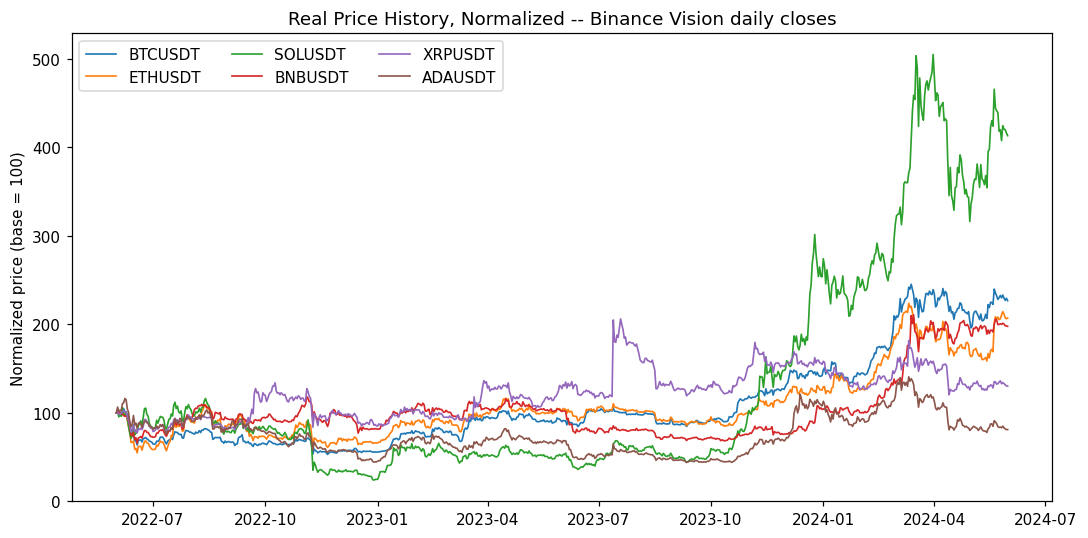

In [3]:
normalized = prices / prices.iloc[0] * 100
fig, ax = plt.subplots(figsize=(10, 5))
for col in normalized.columns:
    ax.plot(normalized.index, normalized[col], label=col, linewidth=1.1)
ax.set_ylabel("Normalized price (base = 100)")
ax.set_title("Real Price History, Normalized -- Binance Vision daily closes")
ax.legend(ncol=3)
fig.tight_layout()
fig.savefig("outputs/figures/price_history_normalized.png", dpi=150)
plt.show()

## 2. Mathematical Framework

For a portfolio of $n$ assets with weight vector $w \in \mathbb{R}^n$
($\sum_i w_i = 1$, $w_i \geq 0$, long-only), annualized mean-return vector
$\mu$, and annualized covariance matrix $\Sigma$:

**Expected portfolio return**
$$E(R_p) = w^\top \mu = \sum_{i=1}^{n} w_i \, \mu_i$$

**Portfolio variance and volatility**
$$\sigma_p^2 = w^\top \Sigma \, w, \qquad \sigma_p = \sqrt{w^\top \Sigma \, w}$$

**Sharpe ratio** (excess return per unit of risk, risk-free rate $R_f$)
$$S(w) = \frac{E(R_p) - R_f}{\sigma_p}$$

**Maximum-Sharpe portfolio**: $\displaystyle \max_{w} S(w)$ subject to
$\sum_i w_i = 1,\ w_i \geq 0$.

**Minimum-volatility portfolio**: $\displaystyle \min_{w} \sigma_p^2$
subject to the same constraints.

**Efficient frontier**: for a target return $\mu^*$, solve
$\min_{w} \sigma_p^2$ subject to $w^\top \mu = \mu^*,\ \sum_i w_i = 1,\ w_i \geq 0$,
sweeping $\mu^*$ across its feasible range. All four problems above are
solved with `scipy.optimize.minimize` (SLSQP), not a closed-form matrix
solution, so the long-only constraint ($w_i \geq 0$) is enforced exactly
rather than approximated.

Crypto trades 365 days/year (no weekend close), so annualization below
uses **365** trading days, not the usual 252 for traditional equities.

In [4]:
daily_returns = po.compute_log_returns(prices)
mean_returns = po.annualize_mean_returns(daily_returns)
cov_matrix = po.annualize_covariance(daily_returns)

summary = pd.DataFrame({
    "Annualized Return": mean_returns,
    "Annualized Volatility": np.sqrt(np.diag(cov_matrix)),
})
summary

,Annualized Return,Annualized Volatility
BTCUSDT,0.409008,0.528540
ETHUSDT,0.363659,0.666942
SOLUSDT,0.709126,1.046005
BNBUSDT,0.340630,0.564826
XRPUSDT,0.131375,0.772679
ADAUSDT,-0.105132,0.720746


In [5]:
correlation = daily_returns.corr()
correlation.style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1).format("{:.2f}")

,BTCUSDT,ETHUSDT,SOLUSDT,BNBUSDT,XRPUSDT,ADAUSDT
BTCUSDT,1.00,0.85,0.71,0.70,0.59,0.73
ETHUSDT,0.85,1.00,0.70,0.70,0.61,0.74
SOLUSDT,0.71,0.70,1.00,0.62,0.56,0.71
BNBUSDT,0.70,0.70,0.62,1.00,0.50,0.63
XRPUSDT,0.59,0.61,0.56,0.50,1.00,0.69
ADAUSDT,0.73,0.74,0.71,0.63,0.69,1.00


## 3. Optimization -- Max Sharpe & Min Volatility

In [6]:
w_sharpe = po.optimize_max_sharpe(mean_returns, cov_matrix)
ret_sharpe, vol_sharpe, sharpe_sharpe = po.portfolio_performance(w_sharpe, mean_returns, cov_matrix)

w_minvol = po.optimize_min_volatility(mean_returns, cov_matrix)
ret_minvol, vol_minvol, sharpe_minvol = po.portfolio_performance(w_minvol, mean_returns, cov_matrix)

results = pd.DataFrame({
    "Max Sharpe": list(w_sharpe) + [ret_sharpe, vol_sharpe, sharpe_sharpe],
    "Min Volatility": list(w_minvol) + [ret_minvol, vol_minvol, sharpe_minvol],
}, index=list(mean_returns.index) + ["Expected Return", "Volatility", "Sharpe Ratio"])
results.round(4)

,Max Sharpe,Min Volatility
BTCUSDT,0.7462,0.5699
ETHUSDT,0.0000,0.0000
SOLUSDT,0.2317,0.0000
BNBUSDT,0.0220,0.3772
XRPUSDT,0.0000,0.0528
ADAUSDT,0.0000,0.0000
Expected Return,0.4770,0.3685
Volatility,0.6003,0.5004
Sharpe Ratio,0.7197,0.6466


## 4. Efficient Frontier

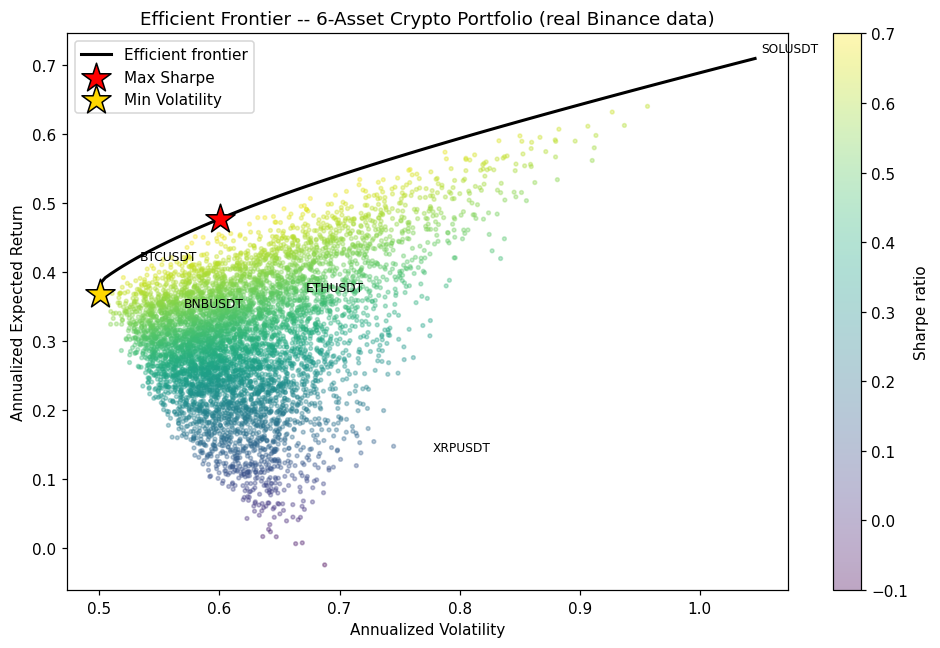

In [7]:
frontier = po.efficient_frontier(mean_returns, cov_matrix, n_points=60)
random_ports = po.random_portfolios(mean_returns, cov_matrix, n_portfolios=6000)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(random_ports["volatility"], random_ports["return"],
                      c=random_ports["sharpe"], cmap="viridis", s=6, alpha=0.35)
fig.colorbar(scatter, label="Sharpe ratio")

ax.plot(frontier["volatility"], frontier["return"], color="black", linewidth=2, label="Efficient frontier")
ax.scatter([vol_sharpe], [ret_sharpe], marker="*", s=400, color="red", edgecolor="black",
           label="Max Sharpe", zorder=5)
ax.scatter([vol_minvol], [ret_minvol], marker="*", s=400, color="gold", edgecolor="black",
           label="Min Volatility", zorder=5)

for asset in mean_returns.index:
    ax.annotate(asset, (np.sqrt(cov_matrix.loc[asset, asset]), mean_returns[asset]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("Annualized Volatility")
ax.set_ylabel("Annualized Expected Return")
ax.set_title("Efficient Frontier -- 6-Asset Crypto Portfolio (real Binance data)")
ax.legend()
fig.tight_layout()
fig.savefig("outputs/figures/efficient_frontier.png", dpi=150)
plt.show()

## 5. Optimal Allocation (Max-Sharpe Portfolio)

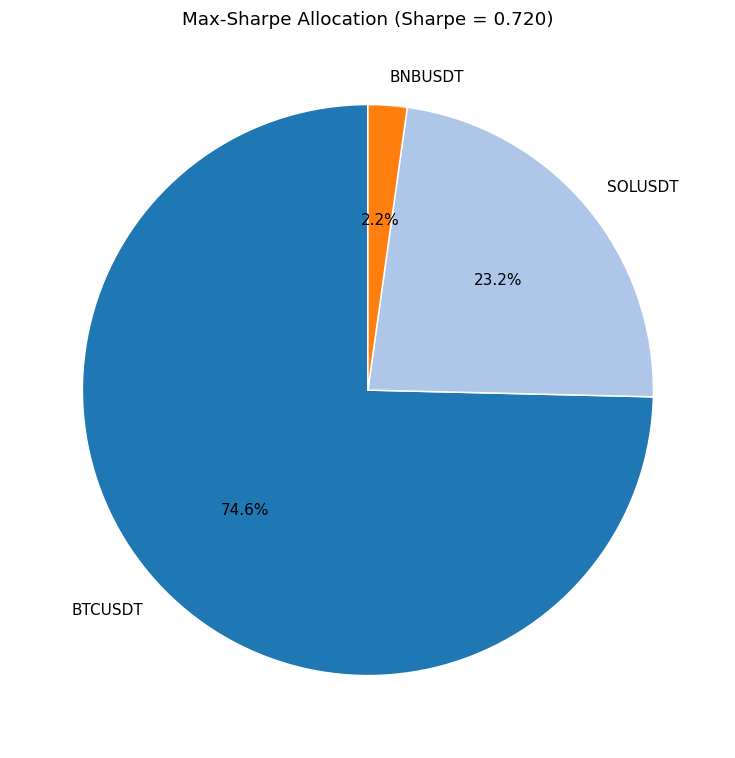

Max-Sharpe weights:
BTCUSDT    0.7462
SOLUSDT    0.2317
BNBUSDT    0.0220
dtype: float64


In [8]:
weights_series = pd.Series(w_sharpe, index=mean_returns.index)
nonzero = weights_series[weights_series > 0.001]

fig, ax = plt.subplots(figsize=(7, 7))
colors = plt.cm.tab20.colors[: len(nonzero)]
ax.pie(nonzero.values, labels=nonzero.index, autopct="%1.1f%%", startangle=90, colors=colors,
       wedgeprops={"edgecolor": "white", "linewidth": 1})
ax.set_title(f"Max-Sharpe Allocation (Sharpe = {sharpe_sharpe:.3f})")
fig.tight_layout()
fig.savefig("outputs/figures/allocation_pie.png", dpi=150)
plt.show()

print("Max-Sharpe weights:")
print(nonzero.round(4))

## 6. Results Persistence (DuckDB)

This is a numerical-optimization problem, not a supervised model, so
there is nothing to persist as a *model* -- instead each run's
allocations, performance (return/volatility/Sharpe), and full efficient
frontier are persisted to a local DuckDB file
() via , so results
stay queryable across runs without re-solving the optimization.

In [9]:
import results_store as rs

rs.save_run(
    rs.DEFAULT_DB_PATH,
    run_label="notebook-run",
    mean_returns=mean_returns,
    w_sharpe=w_sharpe,
    w_minvol=w_minvol,
    perf_sharpe=(ret_sharpe, vol_sharpe, sharpe_sharpe),
    perf_minvol=(ret_minvol, vol_minvol, sharpe_minvol),
    frontier=frontier,
)
rs.load_latest_performance(rs.DEFAULT_DB_PATH)

,run_ts,run_label,portfolio,expected_return,volatility,sharpe
0,2026-08-31T20:40:26.489150+00:00,notebook-run,max_sharpe,0.477043,0.600349,0.719654
1,2026-08-31T20:40:26.489150+00:00,notebook-run,min_volatility,0.368547,0.500404,0.646571


## 7. Conclusion

Over this real 24-month window, the maximum-Sharpe portfolio concentrates
almost entirely in `BTCUSDT` and `SOLUSDT`, with a small `BNBUSDT` stake and
zero allocation to `ETHUSDT`, `XRPUSDT`, and `ADAUSDT` -- `ADAUSDT` in
particular had a **negative** annualized return over this exact period, so
the optimizer correctly excludes it rather than including it for
"diversification" for its own sake. This is a direct, honest consequence
of mean-variance optimization on real historical data, not a hand-picked
result: Markowitz optimization has no notion of a name being a well-known
asset, only of its realized return, risk, and correlation to the rest of
the basket.